# <a id='toc1_'></a>[continuous vs pulsed excitation](#toc0_)

In [16]:
import numpy as np

import fluopy.emissions as em
import fluopy.fcs as fcs_p
import fluopy.figure as fi
import fluopy.fluorophores as fl
import fluopy.transitions as tr

%load_ext autoreload
%autoreload 2

saving_at = (
    r"C:\Users\vie43sq\data_vincent\python_output\Chapter_I\1_12_multi_f_antibunching"
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## S0 S1

In [68]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", count=4, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores)
exc = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[0, 1, 2, 3]
)
flu = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e8,
    fluorophore_ids=[0, 1, 2, 3],
)
ic = tr.Transition(
    transition_type=tr.TransitionType.INTERNAL_CONVERSION_S,
    rate=1e9,
    fluorophore_ids=[0, 1, 2, 3],
)
transitions = {"cy5_dna": [exc, flu, ic]}
transition_set = tr.TransitionSet(transitions, fluorophore_system)

### Continuous excitation

In [39]:
rng = np.random.default_rng(seed=42)
emis = em.Emissions(frame_time="1ms", seed=rng)
emis.simulate(transition_set=transition_set, frames=10000, store_time_points=True)

In [40]:
rng = np.random.default_rng(seed=42)
hist, bin_centers = fcs_p.coincidence(
    emis.event_time_points, tau_max=1e-7, bin_width=5e-10, seed=rng, method="numba"
)

In [41]:
hist[195:205], bin_centers[195:205]

(array([1.00515353, 0.93854697, 0.92643669, 0.92038155, 0.72056187,
        0.80533385, 0.82349928, 0.98093297, 1.11414608, 1.05964981]),
 array([-2.25e-09, -1.75e-09, -1.25e-09, -7.50e-10, -2.50e-10,  2.50e-10,
         7.50e-10,  1.25e-09,  1.75e-09,  2.25e-09]))

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

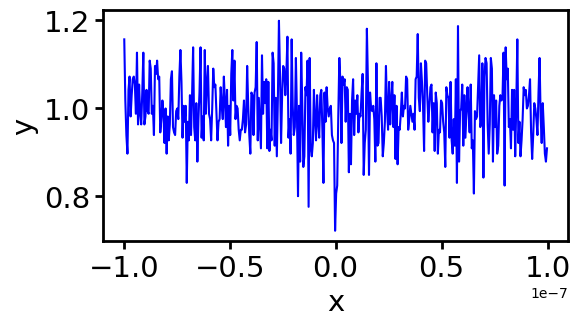

In [42]:
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
)

### Pulsed excitation

In [59]:
rng = np.random.default_rng(seed=42)
emis = em.Emissions(frame_time="1ms", seed=rng)
_, _, _, _ = emis.tcspc(
    transition_set=transition_set,
    pulse_duration=5e-11,
    time_between_pulses=1.25e-8,
    number_pulses=1e8,
    store_time_points=True,
)

The irradiance used initially for excitation rates in
 transition_set is now assumed to be the mean irradiance of
 pulse and no pulse duration.
the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames.


In [60]:
rng = np.random.default_rng(seed=42)
hist, bin_centers = fcs_p.coincidence(
    emis.event_time_points, tau_max=1e-7, bin_width=5e-10, seed=rng, method="numba"
)

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

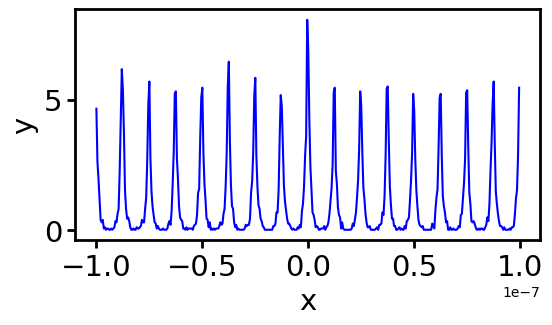

In [61]:
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
)

### 1 F

In [64]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", count=1, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores)
exc = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[0]
)
flu = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e8,
    fluorophore_ids=[0],
)
ic = tr.Transition(
    transition_type=tr.TransitionType.INTERNAL_CONVERSION_S,
    rate=1e9,
    fluorophore_ids=[0],
)
transitions = {"cy5_dna": [exc, flu, ic]}
transition_set = tr.TransitionSet(transitions, fluorophore_system)

In [65]:
rng = np.random.default_rng(seed=42)
emis = em.Emissions(frame_time="1ms", seed=rng)
_, _, _, _ = emis.tcspc(
    transition_set=transition_set,
    pulse_duration=5e-11,
    time_between_pulses=1.25e-8,
    number_pulses=1e8,
    store_time_points=True,
)

The irradiance used initially for excitation rates in
 transition_set is now assumed to be the mean irradiance of
 pulse and no pulse duration.
the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames.


In [66]:
rng = np.random.default_rng(seed=42)
hist, bin_centers = fcs_p.coincidence(
    emis.event_time_points, tau_max=1e-7, bin_width=5e-10, seed=rng, method="numba"
)

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

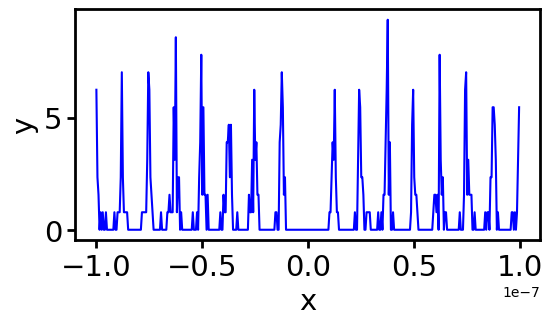

In [67]:
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
)

### 4 f only flu

In [69]:
fluorophores = fl.construct_fluorophores(
    name="cy5_dna", count=4, distance=3, shape="square"
)
fluorophore_system = fl.FluorophoreSystem(fluorophores)
exc = tr.Transition(
    transition_type=tr.TransitionType.EXCITATION, rate=1e6, fluorophore_ids=[0, 1, 2, 3]
)
flu = tr.Transition(
    transition_type=tr.TransitionType.FLUORESCENT_EMISSION,
    rate=1e8,
    fluorophore_ids=[0, 1, 2, 3],
)
ic = tr.Transition(
    transition_type=tr.TransitionType.INTERNAL_CONVERSION_S,
    rate=1e9,
    fluorophore_ids=[0, 1, 2, 3],
)
transitions = {"cy5_dna": [exc, flu, ic]}
transitions = {"cy5_dna": [exc, flu]}
transition_set = tr.TransitionSet(transitions, fluorophore_system)

In [70]:
rng = np.random.default_rng(seed=42)
emis = em.Emissions(frame_time="1ms", seed=rng)
_, _, _, _ = emis.tcspc(
    transition_set=transition_set,
    pulse_duration=5e-11,
    time_between_pulses=1.25e-8,
    number_pulses=1e8,
    store_time_points=True,
)

The irradiance used initially for excitation rates in
 transition_set is now assumed to be the mean irradiance of
 pulse and no pulse duration.
the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames.


In [71]:
rng = np.random.default_rng(seed=42)
hist, bin_centers = fcs_p.coincidence(
    emis.event_time_points, tau_max=1e-7, bin_width=5e-10, seed=rng, method="numba"
)

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

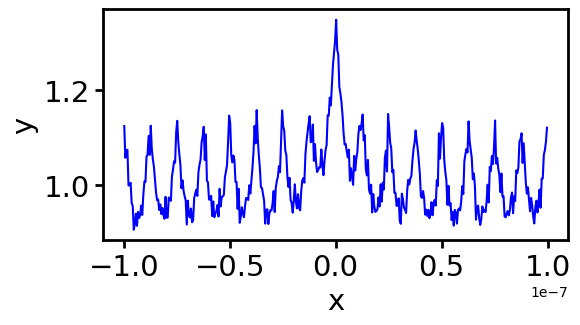

: 

In [ ]:
fi.universal_figure(
    type_="line",
    data=[bin_centers, hist],
)